# Here we process blocks 1 and 2 to get static and atmospheric information

In [13]:
from irrigator.config import load_region_config, load_parcel_config
from irrigator.static_layers import get_soil_profile, get_terrain_params
from irrigator.static_layers.terrain import get_era5_elevation
from irrigator.atmospheric.era5_processor import process_era5_to_daily, save_daily, load_daily
from irrigator.atmospheric.forcing import extract_parcel_forcing
from irrigator.ingestion.cds_client import open_era5_land
import os

In [14]:
PARENT = str(os.path.dirname(os.getcwd()))

cfg = load_region_config(PARENT + "/configs/dordogne.yaml")
parcel = load_parcel_config(PARENT + "/configs/parcels/example.yaml")


In [16]:

# Block 1: static layers
soil = get_soil_profile(cfg, parcel)
terrain = get_terrain_params(cfg, parcel)
terrain.era5_elevation_m = get_era5_elevation(cfg, parcel)


In [8]:

# Block 2: atmospheric forcing
# First time: process hourly → daily (slow, do once)
era5_hourly = open_era5_land(cfg)
era5_daily = process_era5_to_daily(era5_hourly)
save_daily(era5_daily, cfg)


In [17]:
# After that: just load
era5_daily = load_daily(cfg)

# Extract forcing at parcel (with downscaling)
forcing = extract_parcel_forcing(era5_daily, parcel, terrain)
df = forcing.to_dataframe()
df.head()


,t_min,t_max,t_mean,dewpoint,wind_speed_2m,pressure_kpa,rs_mj,precip_mm
date,,,,,,,,
2000-01-01,5.012279,6.407787,5.679180,5.611278,0.618926,98.078033,11.609546,17.934486
2000-01-02,3.792736,7.660747,5.858501,4.469097,1.016541,98.221100,36.345668,1.455118
2000-01-03,1.761242,7.406932,4.191814,2.246135,1.742059,98.120651,70.134886,0.085923
2000-01-04,2.283764,7.584606,4.948162,3.728740,2.225215,97.914948,63.462107,2.920656
2000-01-05,5.871532,9.300121,6.795055,5.467022,1.557284,97.584785,46.737369,17.735947


<Axes: xlabel='date'>

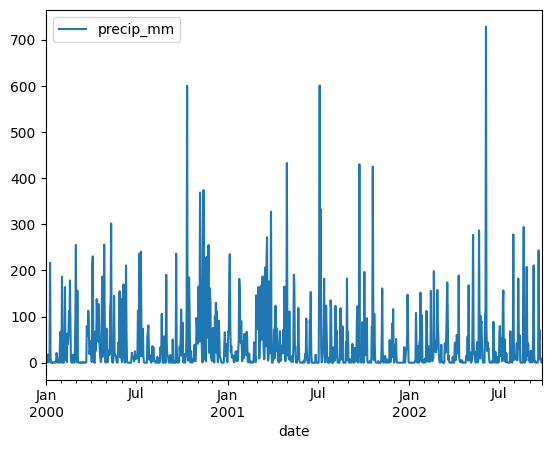

In [20]:
df.iloc[:1000,7:8].plot()

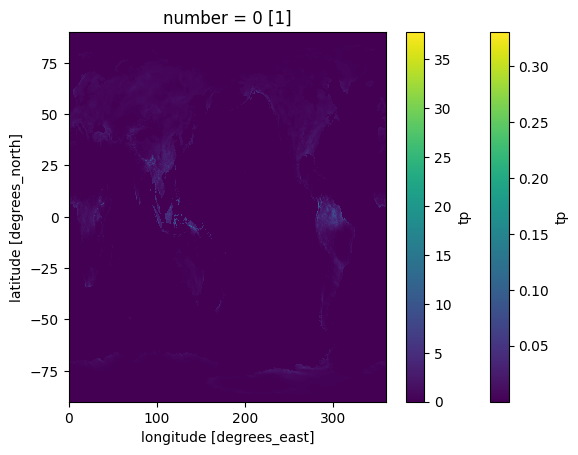

In [11]:
import xarray as xr
path_file = "/home/mbaldacchino/data/33505eca68b53c918b645961f7affd94/data_0.nc"
tst = xr.open_dataset(path_file)
tp_max = tst.tp.max(["valid_time"])
tp_max.plot()
tp_sum = tst.tp.sum(["valid_time"])
tp_sum.plot()
